In [69]:
import numpy as np
from sympy import symbols, Matrix
import cv2
import matplotlib.pyplot as plt

In [91]:
np.set_printoptions(precision=2, floatmode='maxprec', suppress=False)

def skew_symmetric(t):
    return np.array([
        [0, -t[2, 0], t[1, 0]],
        [t[2, 0], 0, -t[0, 0]],
        [-t[1, 0], t[0, 0], 0]
    ])

def normalise(x, w, h):
    homogenous_x = np.hstack([x, 1])
    y = np.array([[2 / w, 0, -1], [0, 2 / h, -1], [0, 0, 1]])
    res = y @ homogenous_x
    res = np.ravel(res)
    res /= res[2]
    res_2d = res[:2]
    return res_2d

foo = normalise([1, 2], 10, 20)
print(foo)

[-0.8 -0.8]


Task 2 (ii)

In [71]:
d = symbols('d')
rt = Matrix([[0, 1, 0, 0], [0, 0, 1, -d], [1, 0, 0, 6 * d]])
k = Matrix([[800, 0, 350], [0, 720, 250], [0, 0, 1]])
origin = Matrix([0, 0, 0, 1])
origin_camera = k * rt * origin
origin_camera_scaled = origin_camera / origin_camera[2]
print(origin_camera)
print(origin_camera_scaled)

Matrix([[2100*d], [780*d], [6*d]])
Matrix([[350], [130], [1]])


Task 3

(a)

1024 1280
1024 1280


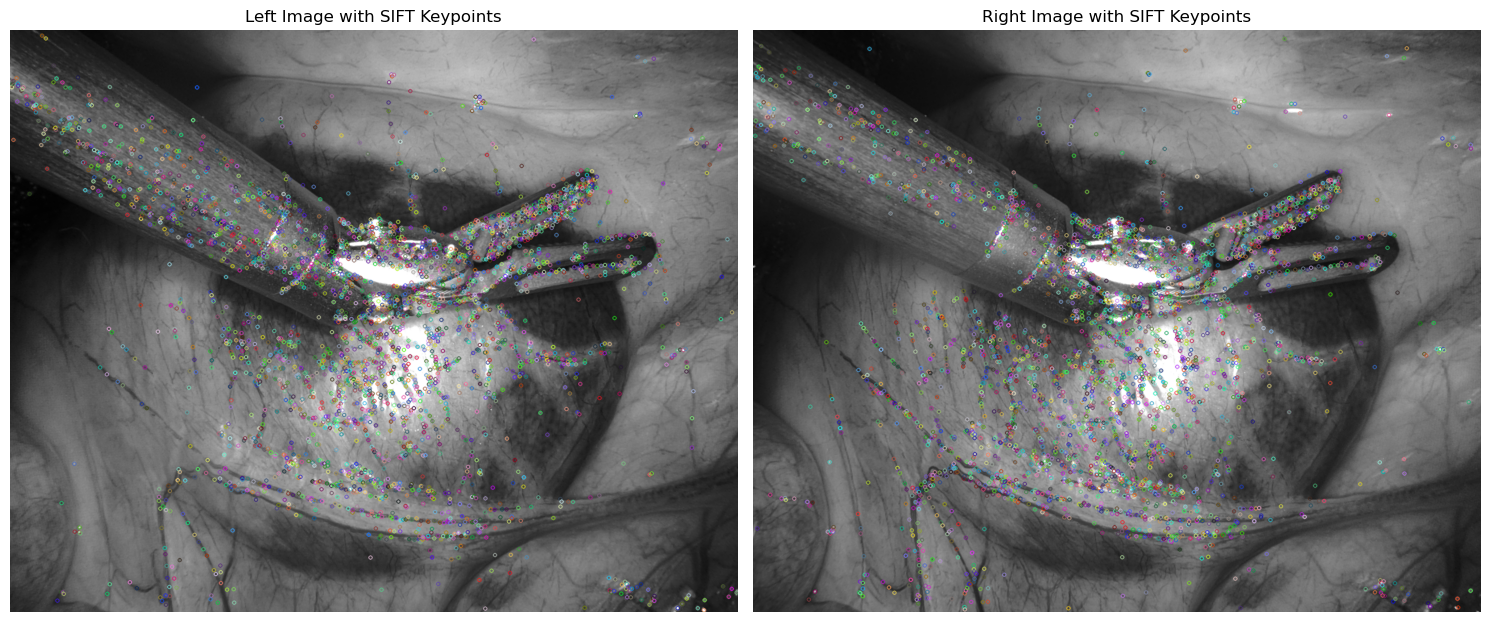

In [72]:
prefix = '/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-3-data/'
# Load the stereo images
left_image = cv2.imread(f'{prefix}left.png', cv2.IMREAD_GRAYSCALE)
right_image = cv2.imread(f'{prefix}right.png', cv2.IMREAD_GRAYSCALE)
left_height, left_width = left_image.shape[:2]
right_height, right_width = right_image.shape[:2]
print(left_height, left_width)
print(right_height, right_width)

# Check if the images are loaded correctly
if left_image is None or right_image is None:
    raise ValueError("One or both images could not be loaded. Check the file paths.")

# Initialize the SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints_left, descriptors_left = sift.detectAndCompute(left_image, None)
keypoints_right, descriptors_right = sift.detectAndCompute(right_image, None)

# Draw the keypoints on the images
left_image_with_keypoints = cv2.drawKeypoints(left_image, keypoints_left, None)
right_image_with_keypoints = cv2.drawKeypoints(right_image, keypoints_right, None)

# Plot the images with keypoints
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
plt.imshow(left_image_with_keypoints, cmap='gray')
plt.title('Left Image with SIFT Keypoints')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(right_image_with_keypoints, cmap='gray')
plt.title('Right Image with SIFT Keypoints')
plt.axis('off')

plt.tight_layout()
plt.show()

(b)

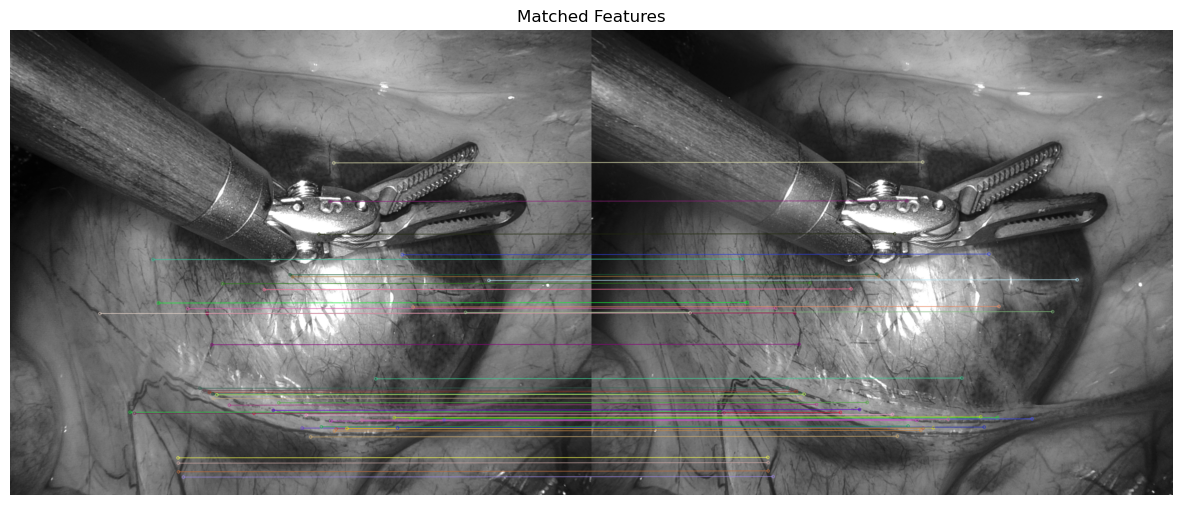

In [73]:
# bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
# matches = bf.match(descriptors_left, descriptors_right)

# Match descriptors using BFMatcher with k=2 to get the two nearest matches
bf = cv2.BFMatcher(cv2.NORM_L2)
knn_matches = bf.knnMatch(descriptors_left, descriptors_right, k=2)

# Apply the ratio test
ratio_thresh = 0.75
matches = [m for m, n in knn_matches if m.distance < ratio_thresh * n.distance]

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# Select the top N matches for visualization
num_matches = 50
good_matches = matches[:num_matches]

# Draw matches using OpenCV's built-in function
matched_image = cv2.drawMatches(left_image, keypoints_left, right_image, keypoints_right, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the result
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Matched Features')
plt.show()

(c)

data from pdf

In [74]:
k1 = np.array([
[1.02408777e+03, 0., 6.01806702e+02],
[0., 1.02389478e+03, 5.08131683e+02],
[0., 0., 1. ]
])

k2 =  np.array([
[1.02419836e+03, 0., 6.96750427e+02],
[0., 1.02398749e+03, 5.07494263e+02],
[0., 0., 1.]
])

r =  np.array([
[9.99999404e-01, -1.24090354e-06, -1.11142127e-03],
[1.29263049e-06, 1., 4.65405355e-05],
[1.11142127e-03, -4.65419434e-05, 9.99999404e-01]
])

t =   np.array([
[-4.34818459e+00],
[2.83603016e-02],
[-9.00963729e-04]
])

rt = np.hstack((r, t))
print(rt)

c1_distortion =  np.array([ -2.52257544e-03, 4.38565714e-03, 0., 0., 9.21500759e-05 ])
[c1_k1, c1_k2, c1_p1, c1_p2, c1_p3] = c1_distortion

c2_distortion =  np.array([ -3.26306466e-03, 5.70008671e-03, 0., 0., 7.57322850e-05 ])
[c2_k1, c2_k2, c2_p1, c2_p2, c2_p3] = c2_distortion

[[ 1.00e+00 -1.24e-06 -1.11e-03 -4.35e+00]
 [ 1.29e-06  1.00e+00  4.65e-05  2.84e-02]
 [ 1.11e-03 -4.65e-05  1.00e+00 -9.01e-04]]


fundamental matrix from stereo

[[881.62 855.55]
 [661.44 895.96]
 [433.61 624.68]
 ...
 [851.42 386.33]
 [915.28 357.84]
 [807.07 472.23]]
[[ 0.38  0.67]
 [ 0.03  0.75]
 [-0.32  0.22]
 ...
 [ 0.33 -0.25]
 [ 0.43 -0.3 ]
 [ 0.26 -0.08]]
Fundamental Matrix (distorted):
 [[-2.29e-07  1.14e-05 -8.00e-02]
 [-3.25e-06 -8.72e-06  2.58e+00]
 [ 7.62e-02 -2.57e+00  1.00e+00]]
Fundamental Matrix (undistorted):
 None


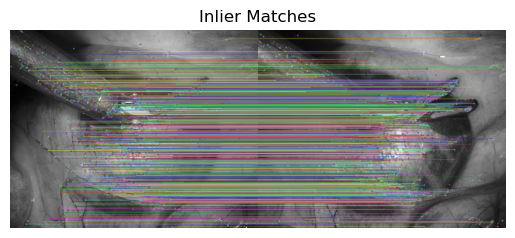

In [ ]:
# Suppose `matches` is a sorted list of DMatch objects
# `keypoints_left` and `keypoints_right` are the keypoints from the two images

# Extract points from the matches
pts_left = np.float32([keypoints_left[m.queryIdx].pt for m in matches])
pts_right = np.float32([keypoints_right[m.trainIdx].pt for m in matches])

pts_left_normalised = np.array([normalise(x, left_width, left_height) for x in pts_left])

k1_dummy = np.array([[1, 0, left_width / 2],
                     [0, 1, left_height / 2],
                     [0, 0, 1]])

k2_dummy = np.array([[1, 0, right_width / 2],
                     [0, 1, right_height / 2],
                     [0, 0, 1]])

# Undistort the points using cv2.undistortPoints
# The undistortPoints function expects the points in normalized camera coordinates
undistorted_pts_left = cv2.undistortPoints(pts_left, k1_dummy, c1_distortion)
print(pts_left)
print(pts_left_normalised)
undistorted_pts_right = cv2.undistortPoints(pts_right, k2_dummy, c2_distortion)

fundamental_matrix, inliers = cv2.findFundamentalMat(pts_left, pts_right, method=cv2.FM_RANSAC)
inlier_matches = [matches[i] for i in range(len(matches)) if inliers[i]]
print("Fundamental Matrix (distorted):\n", fundamental_matrix)
result_image = cv2.drawMatches(left_image, keypoints_left, right_image, keypoints_right, inlier_matches, None)

undistorted_fundamental_matrix, undistorted_inliers = cv2.findFundamentalMat(undistorted_pts_left, undistorted_pts_right, method=cv2.FM_RANSAC)
print("Fundamental Matrix (undistorted):\n", undistorted_fundamental_matrix)

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Inlier Matches')
plt.show()

fundamental matrix from camera parameters (ChatGPT)

In [76]:
# Compute the skew-symmetric matrix of t
t_skew = skew_symmetric(t)

# Compute the fundamental matrix
f = np.linalg.inv(k2).T @ t_skew @ r @ np.linalg.inv(k1)

# Normalize f for consistency
f /= f[-1, -1]

print("Fundamental Matrix (ChatGPT):")
print(f)

Fundamental Matrix (ChatGPT):
[[ 1.98e-08  5.65e-07  1.79e-02]
 [ 2.47e-06 -1.27e-07  2.79e+00]
 [-1.95e-02 -2.79e+00  1.00e+00]]


fundamental matrix from camera parameters (lecture slides)

In [77]:
f_mine = skew_symmetric(k2 @ t) @ k2 @ r @ np.linalg.inv(k1)

f_mine /= f_mine[-1, -1]

print("Fundamental Matrix (lecture slides):")
print(f_mine)

Fundamental Matrix (lecture slides):
[[ 1.98e-08  5.65e-07  1.79e-02]
 [ 2.47e-06 -1.27e-07  2.79e+00]
 [-1.95e-02 -2.79e+00  1.00e+00]]


compare fundamental matrices

In [78]:
ratio = fundamental_matrix / f_mine
print(ratio)

[[-11.58  20.17  -4.47]
 [ -1.32  68.67   0.92]
 [ -3.91   0.92   1.  ]]


(d)

In [102]:
# Convert points to homogeneous coordinates
pts_left_h = np.hstack((pts_left, np.ones((pts_left.shape[0], 1))))  # Shape: (N, 3)
pts_right_h = np.hstack((pts_right, np.ones((pts_right.shape[0], 1))))  # Shape: (N, 3)

# Compute the epipolar constraint for each pair: point_right.T * F * point_left
# (1, 3) x (3, 3) x (3, 1) = scalar for each point pair
epipolar_constraint = np.einsum('ij,jk,ik->i', pts_right_h, fundamental_matrix, pts_left_h)

# Perform element-wise check if values are close to zero
tolerance = 1e-1  # Adjust tolerance based on your requirements
boolean_array = np.isclose(epipolar_constraint, 0, atol=tolerance)

print(epipolar_constraint)
print(boolean_array)
print(len(boolean_array))
print(len([x for x in boolean_array if x]))
print(len([x for x in boolean_array if not x]))

[ 0.43  0.33 -0.36 ... -1.48 -1.11  3.72]
[False False False ... False False False]
1376
92
1284
